# Tutorial 7 Question 3

We have learnt about unsupervised methods of clustering and expectation maximization in this lecture. Let's see how it can be applied to some real-life situations. In this tutorial question, we will be looking at one of the most dreadful 'clusters' we know - dengue clusters in Singapore*

*Partly inspired by the dengue-related data on the data.gov website: https://data.gov.sg/dataset/dengue-cases. Do check out the website as it has many interesting datasets for download.

Assume you are a environmental agency officer and given a Singapore map annotated with the locations of dengue cases, you want to find out the main clusters of dengue. Knowing where the clusters are allows you to allocate the necessary resources (eg. officers for spot checks, home visits) to the areas which need them most. We have created some fictitious data of the dengue cases for our exercise.

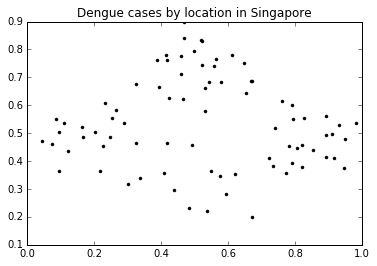

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

dengue_cases = np.loadtxt("dengue_locations.csv",delimiter=',')


plt.plot(dengue_cases[:,0],dengue_cases[:,1],'k.')
plt.title('Dengue cases by location in Singapore')


From the above visualization, we can observe by eye some clusters of the dengue cases. Performing clustering on the data will allow us to identify the cluster areas.


# K means clustering on dengue cases

For the first task, perform Kmeans clustering with 4 clusters. You can choose to use any sklearn functions or write your own K means algorithm. For the outputs, put the cluster centres into an array 'C' and data cluster assignments into the array 'label'.

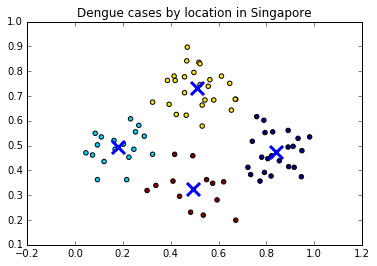

In [3]:
# Task 1: K means clustering (K = 4)
# Output    C : 4x2 array for cluster centres
# Output label: 4x1 array for data cluster assignments
#---------------Answer here--------------------

from sklearn.cluster import KMeans
K = 4
kmeans = KMeans(n_clusters=K, random_state=0).fit(dengue_cases)
C = kmeans.cluster_centers_
labels = kmeans.labels_
Ein = kmeans.inertia_


#--------------Visualization of clusters--------------------
plt.scatter(dengue_cases[:,0],dengue_cases[:,1],c=labels)
plt.title('Dengue cases by location in Singapore')
plt.scatter(C[:,0], C[:,1],marker='x',s=169, linewidths=3)
plt.show()

For your clustering, what is the final clustering quality Ein? Try different initializations and report the lowest Ein you can achieve. 

In [4]:
Ein

1.0410952251002896

For this dengue cluster example, Ein represents how compact the 4 dengue clusters are. We may choose to use the cluster centres as centres of distribution of resources (eg. brochures, mosquito repellents), and Ein here represents how far the residents have to travel to reach their designated distribution centre. The lower Ein is, the happier your residents are.

Now assume we only have resources to set up 3 distribution centres. Perform K means with K = 3 and observe the changes in clustering and Ein. With K = 4, the clusters are approximately the 4 corners of Singapore, north, south, east and west. What happens when K = 3?

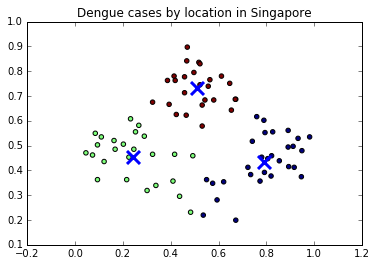

In [5]:
# Task 2: K means clustering (K = 3)
# Output    C : 3x2 array for cluster centres
# Output label: 3x1 array for data cluster assignments
#---------------Answer here--------------------

from sklearn.cluster import KMeans
K = 3
kmeans = KMeans(n_clusters=K, random_state=0).fit(dengue_cases)
C = kmeans.cluster_centers_
labels = kmeans.labels_
Ein = kmeans.inertia_


#--------------Visualization of clusters--------------------
plt.scatter(dengue_cases[:,0],dengue_cases[:,1],c=labels)
plt.title('Dengue cases by location in Singapore')
plt.scatter(C[:,0], C[:,1],marker='x',s=169, linewidths=3)
plt.show()

In [6]:
Ein

1.7444769753863425

Note that the bottom cluster has been absorbed into the other clusters with K = 3. Ein has also increased as compared to K = 4, which is expected.

# GMM with Expectation-Maximization
Let's try clustering on the same data with Gaussian Mixture Models (GMM) with K = 4. Similarly, output arrays 'C' and 'label' for the cluster centres and data labels respectively.

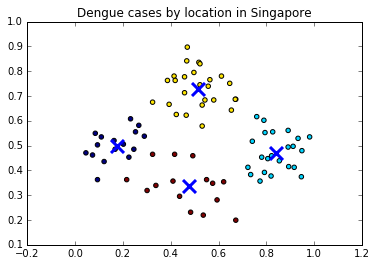

In [21]:
# Task 3: GMM (K = 4)
# Output    C : 4x2 array for cluster centres
# Output label: 4x1 array for data cluster assignments
#---------------Answer here--------------------

from sklearn import mixture
K = 4
gmm = mixture.GaussianMixture(n_components=K, covariance_type='full').fit(dengue_cases)
C = gmm.means_
labels = gmm.predict(dengue_cases)

#--------------Visualization of clusters--------------------
plt.scatter(dengue_cases[:,0],dengue_cases[:,1],c=labels)
plt.title('Dengue cases by location in Singapore')
plt.scatter(C[:,0], C[:,1],marker='x',s=169, linewidths=3)
plt.show()


Initialization is quite tricky with GMM; some students have pointed out that the sklearn algorithm uses K means as a default initialization of the GMM algorithm and that when set as 'random', the fit is very bad. 